# ACP sur les donnees et clustering sur l'ACP

Je refais ici l'**ACP directement en Python**, puis j'enchaine avec les **memes techniques de clustering** que dans `clustering_acm.ipynb`.

L'idee reste la meme :
- lire l'espace factoriel ;
- garder des interpretations courtes et orales ;
- puis comparer plusieurs partitions sur les coordonnees de l'ACP.



## Packages et configuration



In [1]:
import os
import re
from pathlib import Path
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.patches import Ellipse

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import kneighbors_graph, NearestNeighbors
from sklearn.manifold import SpectralEmbedding
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy import sparse

os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.mplconfig'))
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi'] = 120



## Chargement des donnees



In [2]:
DATA_PATH = Path('../../../data/raw/Parcoursup.csv')
df_raw = pd.read_csv(DATA_PATH, sep=';')

print(f'Chemin : {DATA_PATH.resolve()}')
print(f'Dimensions : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes')
display(df_raw.head())



Chemin : /home/gugubre/Projet_analyse_de_donnees_vf/An2DO_4A/data/raw/Parcoursup.csv
Dimensions : 14252 lignes x 118 colonnes


,Session,"Statut de l’établissement de la filière de formation (public, privé…)",Code UAI de l'établissement,Établissement,Code départemental de l’établissement,Département de l’établissement,Région de l’établissement,Académie de l’établissement,Commune de l’établissement,Filière de formation,...,tri,cod_aff_form,Concours communs et banque d'épreuves,Lien de la formation sur la plateforme Parcoursup,Taux d’accès,Part des terminales générales qui étaient en position de recevoir une proposition en phase principale,Part des terminales technologiques qui étaient en position de recevoir une proposition en phase principale,Part des terminales professionnelles qui étaient en position de recevoir une proposition en phase principale,etablissement_id_paysage,composante_id_paysage
0,2025,Public,0692185A,INSTITUT DES SCIENCES ET TECHNIQUES DE LA READ...,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Lyon 8e Arrondissement,Certificat de capacité d'Orthoptiste,...,3_Autres formations,28087,Aix-Marseille Université - Site de Marseille T...,https://dossierappel.parcoursup.fr/Candidats/p...,13,93,7,1,NaN,NaN
1,2025,Public,0931827F,Université Paris 8,93,Seine-Saint-Denis,Ile-de-France,Créteil,Saint-Denis,Licence - Langues étrangères appliquées - Parc...,...,1_universités,28100,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,98,57,24,19,NaN,NaN
2,2025,Public,0421573G,IFSI du CH de Roanne,42,Loire,Auvergne-Rhône-Alpes,Lyon,Roanne,D.E Infirmier,...,3_Autres formations,28144,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,40,56,37,7,NaN,NaN
3,2025,Public,0691774D,Université Claude Bernard Lyon 1,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Villeurbanne,Licence - Parcours d'Accès Spécifique Santé (P...,...,1_universités,28178,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,36,99,1,0,NaN,NaN
4,2025,Public,0691774D,Université Claude Bernard Lyon 1,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Villeurbanne,Licence - Parcours d'Accès Spécifique Santé (P...,...,1_universités,28180,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,20,99,1,0,NaN,NaN


## Preparation des donnees

On reprend ici la logique du preprocessing du fichier R, mais en Python :
- calcul des effectifs sur 2 phases ;
- calcul des taux, pressions et parts de mentions ;
- construction d'un tableau quantitatif propre pour l'ACP ;
- puis quelques variables qualitatives derivees pour commenter les clusters.



In [3]:
def clean_cat(series: pd.Series) -> pd.Series:
    return series.astype('string').str.strip().replace({'': pd.NA, 'nan': pd.NA, 'nd': pd.NA})


def clean_num(series: pd.Series) -> pd.Series:
    return pd.to_numeric(clean_cat(series).str.replace(',', '.', regex=False), errors='coerce')


def clean_pct(series: pd.Series) -> pd.Series:
    return clean_num(clean_cat(series).str.replace('%', '', regex=False)) / 100


def qcut_label(series: pd.Series, labels) -> pd.Series:
    valid = series.dropna()
    cut = pd.qcut(valid, q=len(labels), labels=labels, duplicates='drop')
    out = pd.Series(pd.NA, index=series.index, dtype='object')
    out.loc[valid.index] = cut.astype(str)
    return out.fillna('Non renseigne')


analysis = pd.DataFrame(index=df_raw.index)
analysis['Établissement'] = clean_cat(df_raw['Établissement'])
analysis['Statut brut'] = clean_cat(df_raw['Statut de l’établissement de la filière de formation (public, privé…)'])
analysis['Statut'] = np.select(
    [analysis['Statut brut'].str.startswith('Public', na=False), analysis['Statut brut'].str.startswith('Privé', na=False)],
    ['Public', 'Privé'],
    default=analysis['Statut brut'].fillna('Non renseigne')
)
analysis['Sélectivité'] = clean_cat(df_raw['Sélectivité']).fillna('Non renseigne')
analysis['Filière'] = clean_cat(df_raw['Filière de formation très agrégée']).fillna('Non renseigne')
analysis['Région'] = clean_cat(df_raw['Région de l’établissement']).fillna('Non renseigne')
analysis['Académie'] = clean_cat(df_raw['Académie de l’établissement']).fillna('Non renseigne')

analysis['Capacite'] = clean_num(df_raw['Capacité de l’établissement par formation'])
analysis['Candidats phase principale'] = clean_num(df_raw['Effectif total des candidats en phase principale'])
analysis['Candidats phase complementaire'] = clean_num(df_raw['Effectif total des candidats en phase complémentaire'])
analysis['Admis phase principale'] = clean_num(df_raw['Effectif des admis en phase principale'])
analysis['Admis phase complementaire'] = clean_num(df_raw['Effectif des admis en phase complémentaire'])
analysis['Admis total'] = clean_num(df_raw['Effectif total des candidats ayant accepté la proposition de l’établissement (admis)'])
analysis['Candidates admises'] = clean_num(df_raw['Dont effectif des candidates admises'])
analysis['Admis neobac'] = clean_num(df_raw['Effectif des admis néo bacheliers'])
analysis['Mention AB effectif'] = clean_num(df_raw['Dont effectif des admis néo bacheliers avec mention Assez Bien au bac'])
analysis['Mention B effectif'] = clean_num(df_raw['Dont effectif des admis néo bacheliers avec mention Bien au bac'])
analysis['Mention TB effectif'] = clean_num(df_raw['Dont effectif des admis néo bacheliers avec mention Très Bien au bac'])
analysis['Mention TBF effectif'] = clean_num(df_raw['Dont effectif des admis néo bacheliers avec mention Très Bien avec félicitations au bac'])
analysis['Admis boursiers'] = clean_num(df_raw['Dont effectif des admis boursiers néo bacheliers'])

analysis['Cand gen pp'] = clean_num(df_raw['Effectif des candidats néo bacheliers généraux en phase principale'])
analysis['Cand techno pp'] = clean_num(df_raw['Effectif des candidats néo bacheliers technologiques en phase principale'])
analysis['Cand pro pp'] = clean_num(df_raw['Effectif des candidats néo bacheliers professionnels en phase principale'])
analysis['Boursiers gen pp'] = clean_num(df_raw['Dont effectif des candidats boursiers néo bacheliers généraux en phase principale'])
analysis['Boursiers techno pp'] = clean_num(df_raw['Dont effectif des candidats boursiers néo bacheliers technologiques en phase principale'])
analysis['Boursiers pro pp'] = clean_num(df_raw['Dont effectif des candidats boursiers néo bacheliers professionnels en phase principale'])

analysis['Part meme academie'] = clean_pct(df_raw['% d’admis néo bacheliers issus de la même académie (Paris/Créteil/Versailles réunies)'])
analysis['Part bac general'] = clean_pct(df_raw['% d’admis néo bacheliers généraux'])
analysis['Part bac techno'] = clean_pct(df_raw['% d’admis néo bacheliers technologiques'])
analysis['Part bac pro'] = clean_pct(df_raw['% d’admis néo bacheliers professionnels'])
analysis['Taux acces'] = clean_pct(df_raw['Taux d’accès'])

analysis['Candidats total'] = analysis['Candidats phase principale'].fillna(0) + analysis['Candidats phase complementaire'].fillna(0)
analysis['Admis total 2 phases'] = analysis['Admis phase principale'].fillna(0) + analysis['Admis phase complementaire'].fillna(0)
analysis['pct_filles_admises'] = analysis['Candidates admises'] / analysis['Admis total'].replace(0, np.nan)
analysis['pct_garcons_admis'] = 1 - analysis['pct_filles_admises']
analysis['part_mention_ab'] = analysis['Mention AB effectif'] / analysis['Admis neobac'].replace(0, np.nan)
analysis['part_mention_b'] = analysis['Mention B effectif'] / analysis['Admis neobac'].replace(0, np.nan)
analysis['part_mention_tb'] = analysis['Mention TB effectif'] / analysis['Admis neobac'].replace(0, np.nan)
analysis['part_mention_tb_fel'] = analysis['Mention TBF effectif'] / analysis['Admis neobac'].replace(0, np.nan)
analysis['part_mention_haute'] = analysis['part_mention_tb'].fillna(0) + analysis['part_mention_tb_fel'].fillna(0)
analysis['score_mention'] = (
    analysis['part_mention_ab'].fillna(0)
    + 2 * analysis['part_mention_b'].fillna(0)
    + 3 * analysis['part_mention_tb'].fillna(0)
    + 4 * analysis['part_mention_tb_fel'].fillna(0)
)
analysis['pression_candidature'] = analysis['Candidats total'] / analysis['Capacite'].replace(0, np.nan)
analysis['taux_admission'] = analysis['Admis total 2 phases'] / analysis['Candidats total'].replace(0, np.nan)
analysis['taux_remplissage'] = analysis['Admis total 2 phases'] / analysis['Capacite'].replace(0, np.nan)
analysis['log_candidats'] = np.log1p(analysis['Candidats total'])
analysis['log_admis'] = np.log1p(analysis['Admis total 2 phases'])
analysis['log_capacite'] = np.log1p(analysis['Capacite'])

cand_total_neobac = analysis[['Cand gen pp', 'Cand techno pp', 'Cand pro pp']].sum(axis=1)
boursiers_candidats_total = analysis[['Boursiers gen pp', 'Boursiers techno pp', 'Boursiers pro pp']].sum(axis=1)
analysis['Pourcentage boursiers candidats'] = 100 * boursiers_candidats_total / cand_total_neobac.replace(0, np.nan)
analysis['Pourcentage boursiers admis'] = 100 * analysis['Admis boursiers'] / analysis['Admis neobac'].replace(0, np.nan)

active_vars = [
    'Capacite', 'Admis total 2 phases', 'Candidats total',
    'Pourcentage boursiers candidats', 'Pourcentage boursiers admis',
    'pct_filles_admises', 'pct_garcons_admis',
    'pression_candidature', 'taux_admission', 'taux_remplissage', 'Taux acces',
    'part_mention_ab', 'part_mention_b', 'part_mention_tb', 'part_mention_tb_fel',
    'part_mention_haute', 'score_mention', 'Part meme academie',
    'Part bac general', 'Part bac techno', 'Part bac pro'
]

active_data = analysis[active_vars].copy()
active_data = active_data.apply(lambda s: s.fillna(s.median()), axis=0)

analysis['Taille'] = qcut_label(analysis['Capacite'], ['Petite capacite', 'Capacite moyenne basse', 'Capacite moyenne haute', 'Grande capacite'])
analysis['Pression'] = qcut_label(analysis['pression_candidature'], ['Pression faible', 'Pression moderee', 'Pression forte', 'Pression tres forte'])
analysis['Accès'] = qcut_label(analysis['Taux acces'], ['Acces difficile', 'Acces intermediaire bas', 'Acces intermediaire haut', 'Acces ouvert'])
analysis['Mentions'] = qcut_label(analysis['score_mention'], ['Mentions faibles', 'Mentions intermediaires', 'Mentions elevees', 'Mentions tres elevees'])
analysis['Boursiers'] = qcut_label(analysis['Pourcentage boursiers admis'], ['Peu de boursiers', 'Boursiers assez peu presents', 'Boursiers presents', 'Beaucoup de boursiers'])
analysis['Féminisation'] = pd.cut(analysis['pct_filles_admises'], bins=[-np.inf, 0.40, 0.60, np.inf], labels=['Majoritairement masculine', 'Mixte', 'Majoritairement feminine']).astype('object').fillna('Non renseigne')
profil_max = analysis[['Part bac general', 'Part bac techno', 'Part bac pro']].max(axis=1)
analysis['Profil admis'] = np.select(
    [
        profil_max.lt(0.45),
        analysis['Part bac general'].ge(analysis['Part bac techno']) & analysis['Part bac general'].ge(analysis['Part bac pro']),
        analysis['Part bac techno'].ge(analysis['Part bac general']) & analysis['Part bac techno'].ge(analysis['Part bac pro']),
    ],
    ['Profil mixte', 'Dominante generale', 'Dominante technologique'],
    default='Dominante professionnelle',
)
cluster_profile_df = analysis[['Filière', 'Sélectivité', 'Pression', 'Accès', 'Mentions', 'Boursiers', 'Féminisation', 'Profil admis', 'Taille', 'Statut', 'Région']].astype(str)

print(f'Jeu ACP : {active_data.shape[0]} individus x {active_data.shape[1]} variables actives')
display(active_data.describe().T.round(3))



Jeu ACP : 14252 individus x 21 variables actives


,count,mean,std,min,25%,50%,75%,max
Capacite,14252.0,53.982,99.851,0.0,18.0,30.0,50.0,3400.0
Admis total 2 phases,14252.0,46.362,76.367,0.0,14.0,25.0,46.0,2187.0
Candidats total,14252.0,947.403,1584.182,1.0,160.0,385.0,1016.0,19404.0
Pourcentage boursiers candidats,14252.0,21.223,11.687,0.0,12.777,19.483,27.674,100.0
Pourcentage boursiers admis,14252.0,22.695,17.465,0.0,10.0,20.0,31.818,100.0
pct_filles_admises,14252.0,0.507,0.291,0.0,0.267,0.536,0.75,1.0
pct_garcons_admis,14252.0,0.493,0.291,0.0,0.25,0.464,0.733,1.0
pression_candidature,14252.0,21.101,33.514,0.05,6.171,11.417,23.5,904.667
taux_admission,14252.0,0.088,0.071,0.0,0.036,0.07,0.12,1.0
taux_remplissage,14252.0,0.836,0.259,0.0,0.733,0.933,1.0,2.941


## ACP - Analyse en composantes principales

On estime maintenant l'ACP sur les **variables quantitatives**, puis on regarde :
- l'inertie par axe ;
- les variables qui portent les axes ;
- la qualite de representation ;
- et quelques lectures d'individus avant de passer au clustering.



In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(active_data)

pca = PCA(n_components=5)
row_coords_pca = pd.DataFrame(pca.fit_transform(X_scaled), index=active_data.index)
eigenvalues = pca.explained_variance_
eig_pct = pca.explained_variance_ratio_ * 100

var_cor = pd.DataFrame(
    pca.components_.T * np.sqrt(eigenvalues),
    index=active_vars,
    columns=row_coords_pca.columns,
)
var_cos2 = var_cor.pow(2)
var_contrib = var_cos2.div(eigenvalues, axis=1) * 100
ind_dist2 = pd.Series((X_scaled ** 2).sum(axis=1), index=active_data.index)
ind_cos2 = row_coords_pca.pow(2).div(ind_dist2, axis=0)

eig_df = pd.DataFrame({
    'Dimension': range(1, len(eigenvalues) + 1),
    'Valeur propre': eigenvalues,
    '% variance': eig_pct,
    '% cumule': np.cumsum(eig_pct),
})

display(eig_df.round(3))



,Dimension,Valeur propre,% variance,% cumule
0,1,5.286,25.172,25.172
1,2,2.417,11.507,36.679
2,3,2.226,10.599,47.278
3,4,1.824,8.683,55.961
4,5,1.598,7.608,63.570


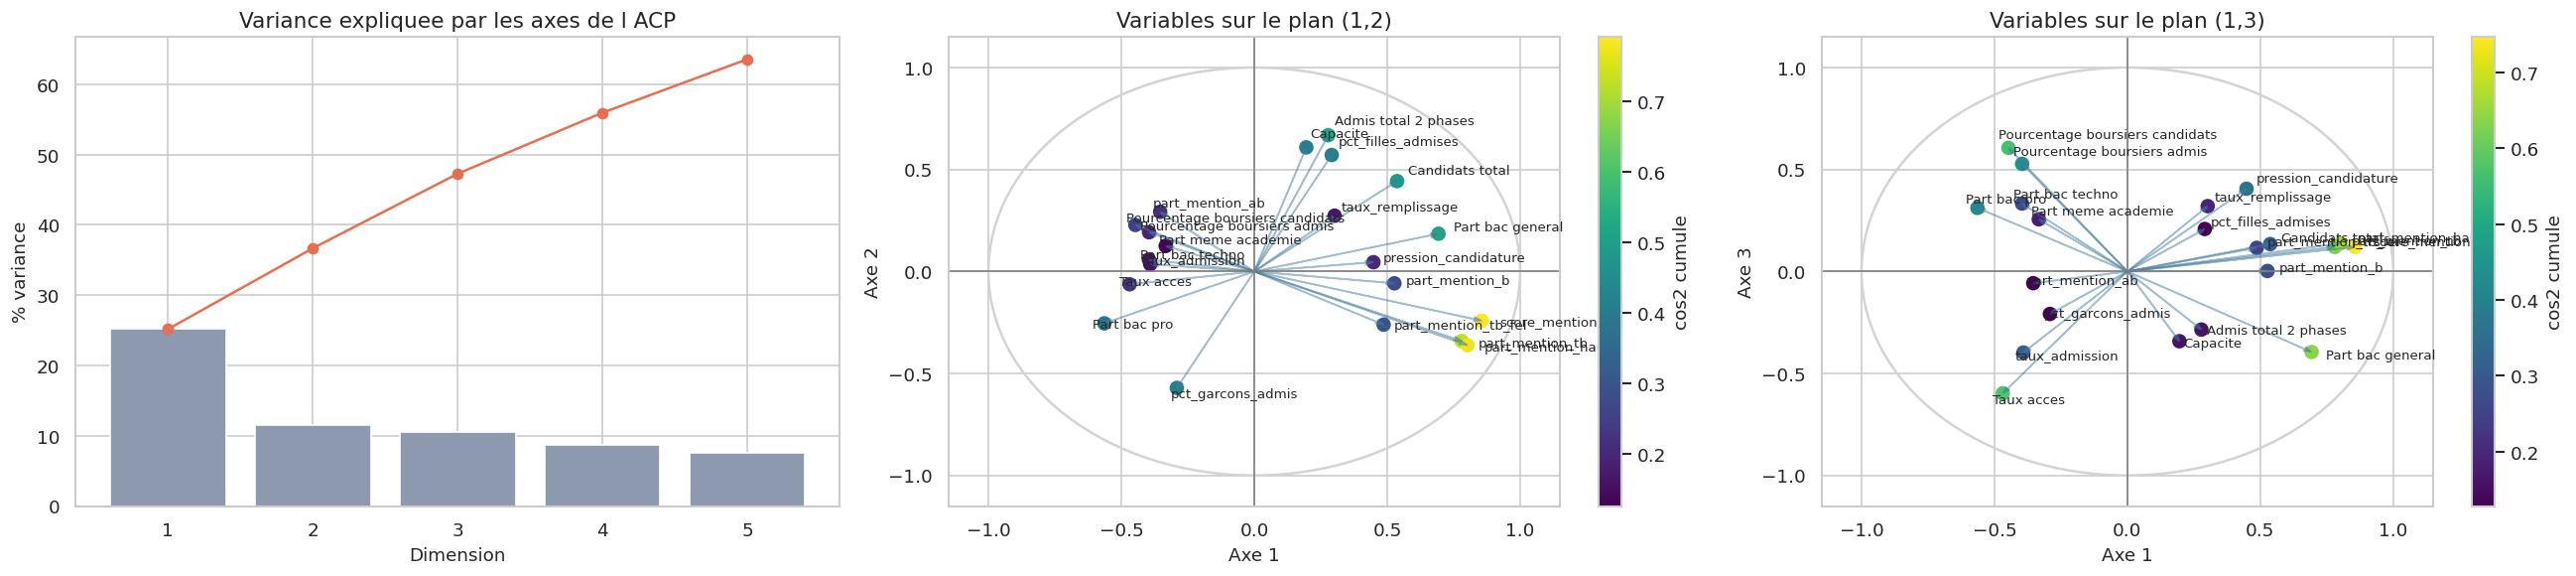

Top contributions a l axe 1 :


,contribution_axe1
score_mention,13.855763
part_mention_haute,12.168005
part_mention_tb,11.510048
Part bac general,9.085512
Part bac pro,6.014493
Candidats total,5.460827
part_mention_b,5.253696
part_mention_tb_fel,4.480860
Taux acces,4.155674
pression_candidature,3.800530


Top contributions a l axe 2 :


,contribution_axe2
Admis total 2 phases,18.473904
Capacite,15.323458
pct_filles_admises,13.500594
pct_garcons_admis,13.500594
Candidats total,8.125632
part_mention_haute,5.396488
part_mention_tb,4.810005
part_mention_ab,3.538144
taux_remplissage,3.097980
part_mention_tb_fel,2.814163


Top contributions a l axe 3 :


,contribution_axe3
Pourcentage boursiers candidats,16.510552
Taux acces,16.047955
Pourcentage boursiers admis,12.505982
pression_candidature,7.392445
taux_admission,7.104901
Part bac general,7.012358
Capacite,5.255671
Part bac techno,4.983556
taux_remplissage,4.614322
Part bac pro,4.366493


In [5]:
def plot_correlation_circle(cor_df, cos2_df, axes=(0, 1), ax=None, title='Cercle des correlations'):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    x_ax, y_ax = axes
    circle = plt.Circle((0, 0), 1, facecolor='none', edgecolor='lightgrey', lw=1.5)
    ax.add_patch(circle)
    color = (cos2_df[x_ax] + cos2_df[y_ax]).rename('cos2')
    sc = ax.scatter(cor_df[x_ax], cor_df[y_ax], c=color, cmap='viridis', s=60)
    for var, row in cor_df[[x_ax, y_ax]].iterrows():
        ax.arrow(0, 0, row[x_ax], row[y_ax], color='#457b9d', alpha=0.45, length_includes_head=True, head_width=0.02)
        ax.text(row[x_ax] * 1.08, row[y_ax] * 1.08, var, fontsize=8)
    ax.axhline(0, color='grey', lw=1)
    ax.axvline(0, color='grey', lw=1)
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_xlabel(f'Axe {x_ax + 1}')
    ax.set_ylabel(f'Axe {y_ax + 1}')
    ax.set_title(title)
    plt.colorbar(sc, ax=ax, label='cos2 cumule')
    return ax

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
axes[0].bar(eig_df['Dimension'], eig_df['% variance'], color='#8d99ae')
axes[0].plot(eig_df['Dimension'], eig_df['% cumule'], color='#e76f51', marker='o')
axes[0].set_title('Variance expliquee par les axes de l ACP')
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('% variance')
plot_correlation_circle(var_cor, var_cos2, axes=(0, 1), ax=axes[1], title='Variables sur le plan (1,2)')
plot_correlation_circle(var_cor, var_cos2, axes=(0, 2), ax=axes[2], title='Variables sur le plan (1,3)')
plt.tight_layout()
plt.show()

print('Top contributions a l axe 1 :')
display(var_contrib[0].sort_values(ascending=False).head(12).to_frame('contribution_axe1'))
print('Top contributions a l axe 2 :')
display(var_contrib[1].sort_values(ascending=False).head(12).to_frame('contribution_axe2'))
print('Top contributions a l axe 3 :')
display(var_contrib[2].sort_values(ascending=False).head(12).to_frame('contribution_axe3'))



### Lecture des axes

On retrouve une structure très proche de celle suggeree dans le notebook R :
- **Axe 1** oppose surtout les formations les plus **selectives**, a **fortes mentions**, forte **pression** et forte part de **bacs generaux**, a des formations plus **ouvertes** et plus **professionnelles** ;
- **Axe 2** ressemble davantage a un axe de **taille** et de **composition du public** ;
- **Axe 3** fait mieux ressortir les **boursiers** et le **taux d'acces**.





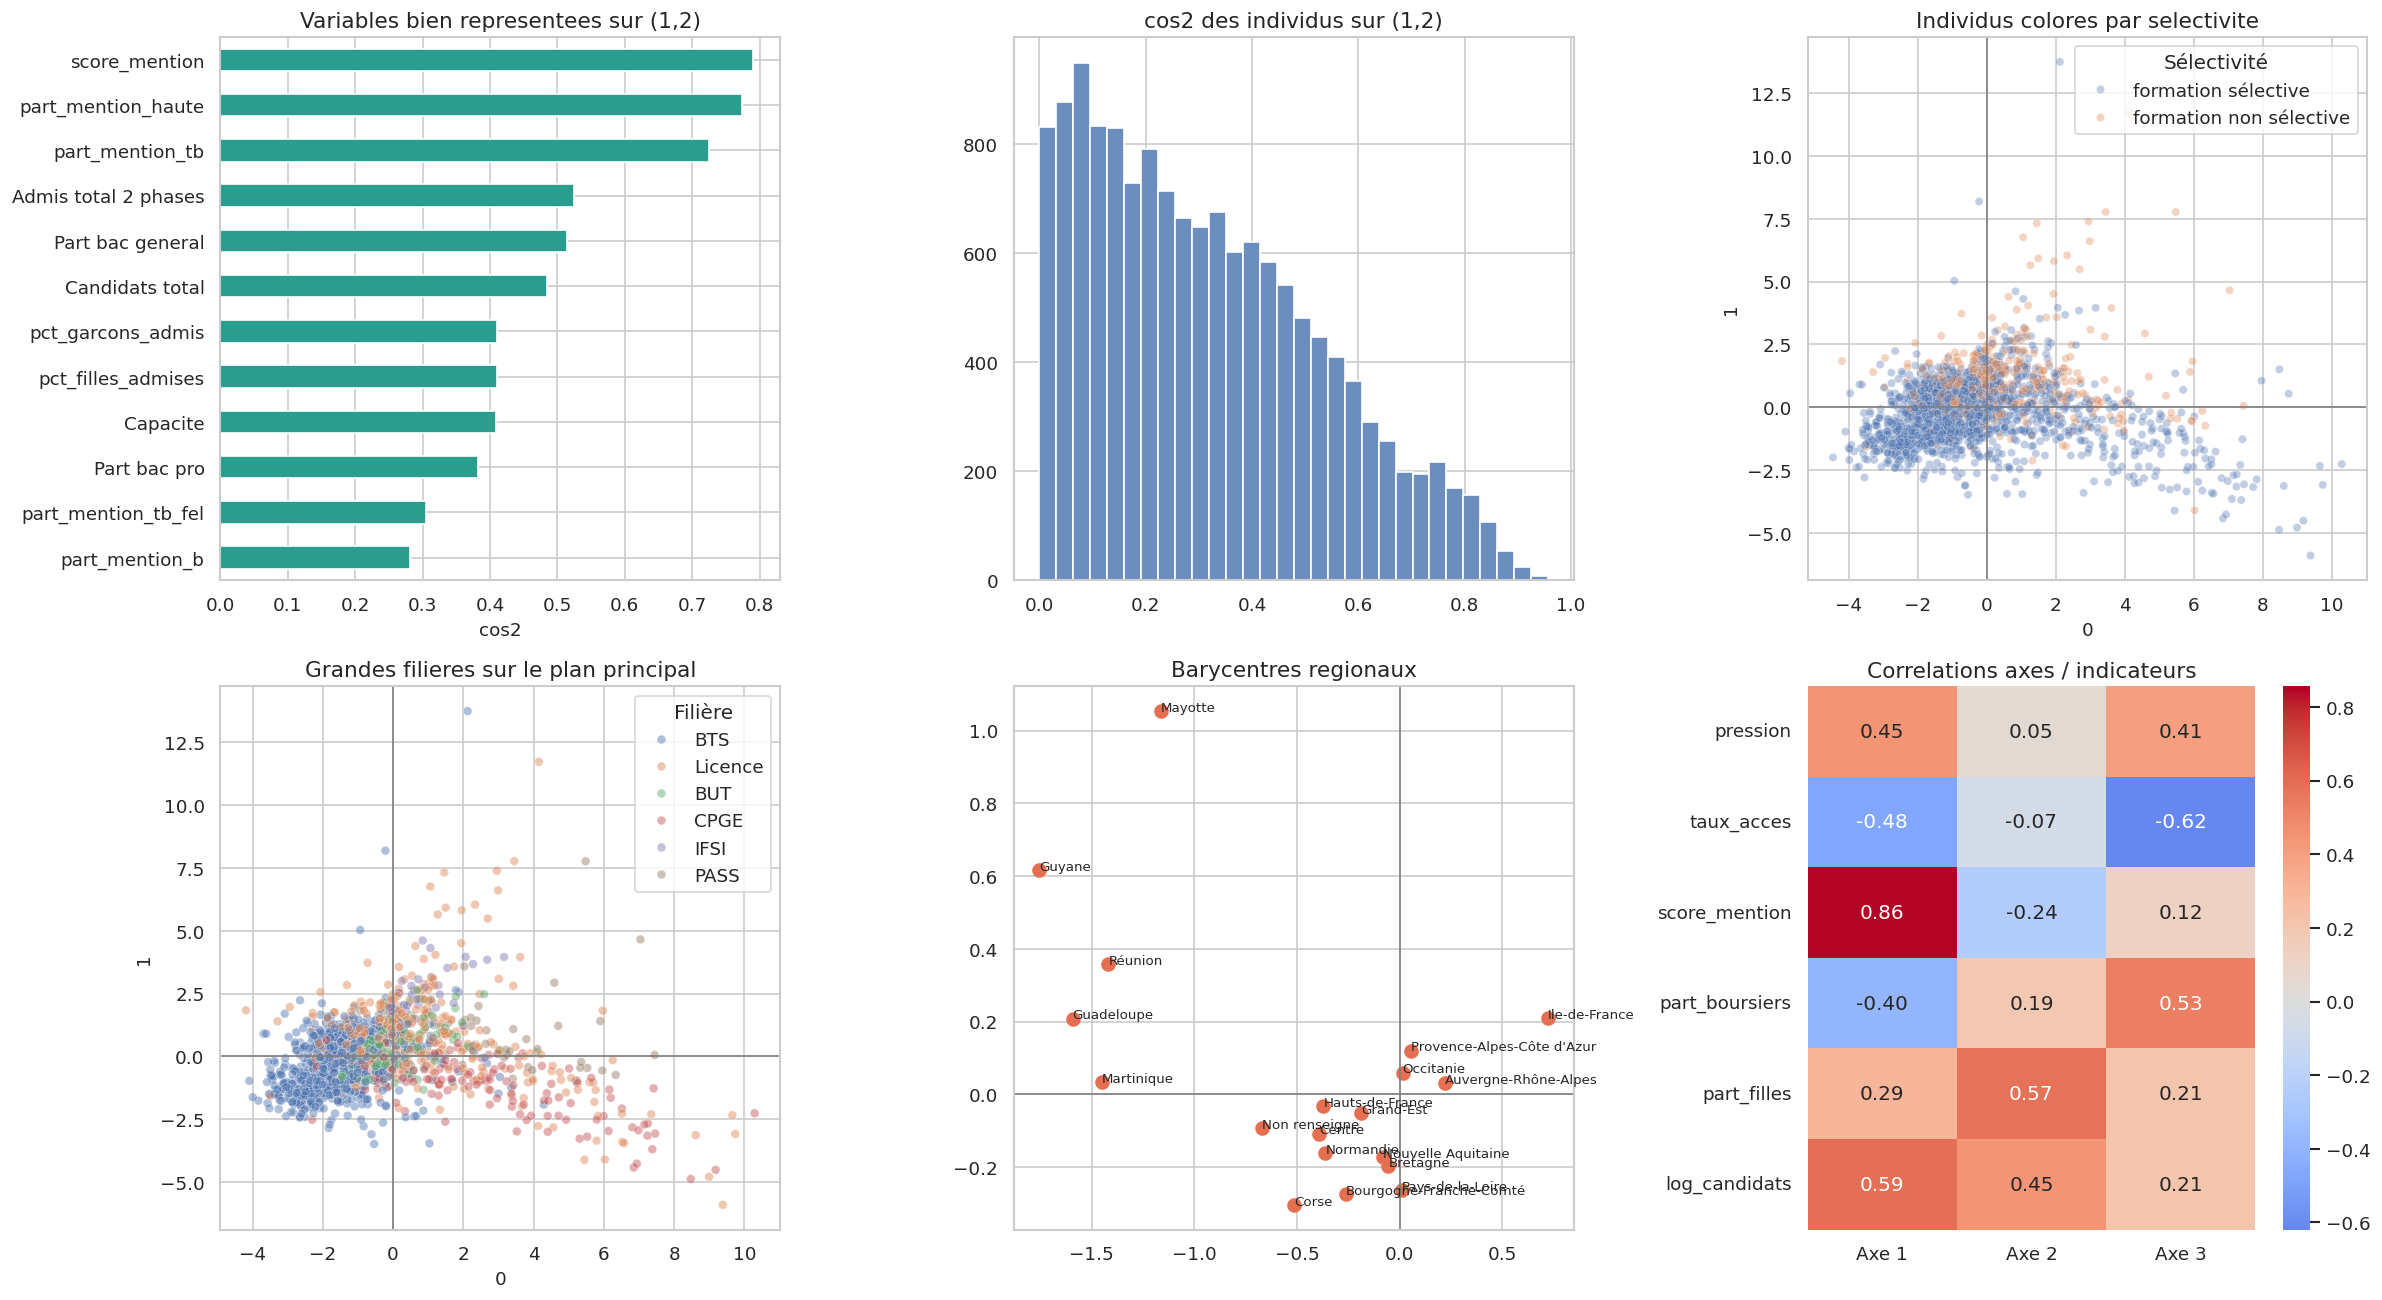

Part des individus avec cos2 plan (1,2) >= 0.2 : 0.631
Part des individus avec cos2 cumule (1,2,3,4) >= 0.5 : 0.583


In [6]:
var_cos2_plane = var_cos2[0] + var_cos2[1]
ind_cos2_plane = ind_cos2[0] + ind_cos2[1]
ind_cos2_4d = ind_cos2[0] + ind_cos2[1] + ind_cos2[2] + ind_cos2[3]

sample_idx = row_coords_pca.sample(n=min(1800, len(row_coords_pca)), random_state=42).index
plot_df = row_coords_pca.loc[sample_idx, [0, 1]].copy()
plot_df['Sélectivité'] = analysis.loc[sample_idx, 'Sélectivité'].values
plot_df['Filière'] = analysis.loc[sample_idx, 'Filière'].values
plot_df['log_candidats'] = analysis.loc[sample_idx, 'log_candidats'].values
plot_df['part_mention_haute'] = analysis.loc[sample_idx, 'part_mention_haute'].values

region_bary = row_coords_pca[[0, 1]].join(analysis['Région']).groupby('Région').mean().sort_values(0)
quanti_sup = pd.DataFrame({
    'pression': analysis['pression_candidature'],
    'taux_acces': analysis['Taux acces'],
    'score_mention': analysis['score_mention'],
    'part_boursiers': analysis['Pourcentage boursiers admis'],
    'part_filles': analysis['pct_filles_admises'],
    'log_candidats': analysis['log_candidats'],
})
correlations = pd.DataFrame({f'Axe {dim + 1}': quanti_sup.apply(lambda s: s.corr(row_coords_pca[dim])) for dim in range(3)})

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
var_cos2_plane.sort_values(ascending=False).head(12).sort_values().plot(kind='barh', ax=axes[0, 0], color='#2a9d8f')
axes[0, 0].set_title('Variables bien representees sur (1,2)')
axes[0, 0].set_xlabel('cos2')

axes[0, 1].hist(ind_cos2_plane, bins=30, color='#6c8ebf', edgecolor='white')
axes[0, 1].set_title('cos2 des individus sur (1,2)')

sns.scatterplot(data=plot_df, x=0, y=1, hue='Sélectivité', alpha=0.35, s=24, ax=axes[0, 2])
axes[0, 2].axhline(0, color='grey', lw=1)
axes[0, 2].axvline(0, color='grey', lw=1)
axes[0, 2].set_title('Individus colores par selectivite')

focus_df = plot_df[plot_df['Filière'].isin(['BTS', 'Licence', 'BUT', 'CPGE', 'PASS', 'IFSI'])].copy()
sns.scatterplot(data=focus_df, x=0, y=1, hue='Filière', alpha=0.45, s=28, ax=axes[1, 0])
axes[1, 0].axhline(0, color='grey', lw=1)
axes[1, 0].axvline(0, color='grey', lw=1)
axes[1, 0].set_title('Grandes filieres sur le plan principal')

axes[1, 1].axhline(0, color='grey', lw=1)
axes[1, 1].axvline(0, color='grey', lw=1)
axes[1, 1].scatter(region_bary[0], region_bary[1], s=60, color='#e76f51')
for idx, (x, y) in region_bary[[0, 1]].iterrows():
    axes[1, 1].text(x, y, idx, fontsize=8)
axes[1, 1].set_title('Barycentres regionaux')

sns.heatmap(correlations, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1, 2])
axes[1, 2].set_title('Correlations axes / indicateurs')

plt.tight_layout()
plt.show()

print(f'Part des individus avec cos2 plan (1,2) >= 0.2 : {(ind_cos2_plane >= 0.2).mean():.3f}')
print(f'Part des individus avec cos2 cumule (1,2,3,4) >= 0.5 : {(ind_cos2_4d >= 0.5).mean():.3f}')



### Lecture synthetique de l'ACP

Le plan principal reste chargé, ce qui est normal avec autant de formations. Mais on voit deja assez bien :
- un pole **tres selectif** et academiquement plus exigeant ;
- un pole plus **professionnalisant** ;
- et un ensemble plus **large / generaliste**, souvent de plus grande taille.

Les axes suivants gardent une partie de l'information, donc il est logique de faire les clusterings sur les **5 premiers axes** plutot que seulement sur le plan `(1,2)`.



## Clustering des individus sur l'espace factoriel de l'ACP



In [7]:
cluster_vars = ['Filière', 'Sélectivité', 'Pression', 'Accès', 'Mentions', 'Profil admis', 'Taille', 'Statut']
acp_cluster_coords = row_coords_pca.iloc[:, :5].copy()
cluster_input = acp_cluster_coords.to_numpy()

print(f'Clustering sur {cluster_input.shape[0]} individus et {cluster_input.shape[1]} axes.')
print(f'Variance cumulee des 5 axes : {eig_df.loc[:4, "% variance"].sum():.2f}%')


def top_modalities_by_cluster(df, labels, columns, top_n=3):
    labels = pd.Series(labels, index=df.index, name='cluster')
    out = []
    for col in columns:
        global_dist = df[col].value_counts(normalize=True)
        for cluster in sorted(labels.unique()):
            sub = df.loc[labels[labels == cluster].index, col]
            dist = sub.value_counts(normalize=True)
            over = (dist / global_dist).sort_values(ascending=False)
            for modality in over.head(top_n).index:
                out.append({'cluster': int(cluster), 'variable': col, 'modalite': modality, 'part_cluster': round(100 * dist.get(modality, 0), 1), 'indice_surrepr': round(float(over[modality]), 2)})
    return pd.DataFrame(out)


def cluster_centroids_table(coords, labels):
    labels = pd.Series(labels, index=coords.index, name='cluster')
    centers = coords.groupby(labels).mean().round(3)
    centers.index.name = 'cluster'
    centers.columns = [f'Axe {i + 1}' for i in range(centers.shape[1])]
    return centers


def plot_clusters_on_factor_plane(coords, labels, title, ax=None, sample_size=2500):
    labels = pd.Series(labels, index=coords.index, name='cluster')
    plot_local = coords[[0, 1]].copy()
    plot_local['cluster'] = labels.astype(str)
    if len(plot_local) > sample_size:
        plot_local = plot_local.sample(sample_size, random_state=42)
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(data=plot_local, x=0, y=1, hue='cluster', alpha=0.45, s=25, ax=ax, palette='Set2')
    ax.axhline(0, color='grey', lw=1)
    ax.axvline(0, color='grey', lw=1)
    ax.set_title(title)
    ax.set_xlabel('Axe 1')
    ax.set_ylabel('Axe 2')
    return ax


def draw_ellipse(mean, covariance, alpha, ax, color):
    U, s, _ = np.linalg.svd(covariance)
    angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
    width, height = 2 * np.sqrt(np.maximum(s, 1e-12))
    ax.add_patch(Ellipse(mean, 4 * width, 4 * height, angle=angle, alpha=alpha, fc=color, ec=color, lw=1))



Clustering sur 14252 individus et 5 axes.
Variance cumulee des 5 axes : 63.57%


### 1 : K-means sur l'ACP

On teste plusieurs `k`, puis on retient `k=3` pour garder une lecture simple.



,k,inertie_intra,silhouette
0,2,142073.3621,0.3418
1,3,116204.8257,0.2274
2,4,102167.0927,0.2357
3,5,88855.1869,0.2268
4,6,79114.0225,0.2216


,effectif
Cluster k-means,
1,5985
2,6730
3,1537


,Axe 1,Axe 2,Axe 3,Axe 4,Axe 5
cluster,,,,,
1,-1.782,-0.462,0.583,-0.424,0.216
2,0.463,0.692,-0.646,0.450,-0.343
3,4.914,-1.233,0.557,-0.318,0.660


,cluster,variable,modalite,part_cluster,indice_surrepr
0,1,Filière,BTS,76.4,2.03
1,1,Filière,Autre formation,10.1,0.79
2,1,Filière,BUT,3.1,0.55
3,2,Filière,IFSI,5.0,2.07
4,2,Filière,Ecole de Commerce,3.2,1.78
...,...,...,...,...,...
61,1,Statut,Public,77.7,1.00
62,2,Statut,Privé,24.5,1.11
63,2,Statut,Public,75.5,0.97
64,3,Statut,Public,89.7,1.15


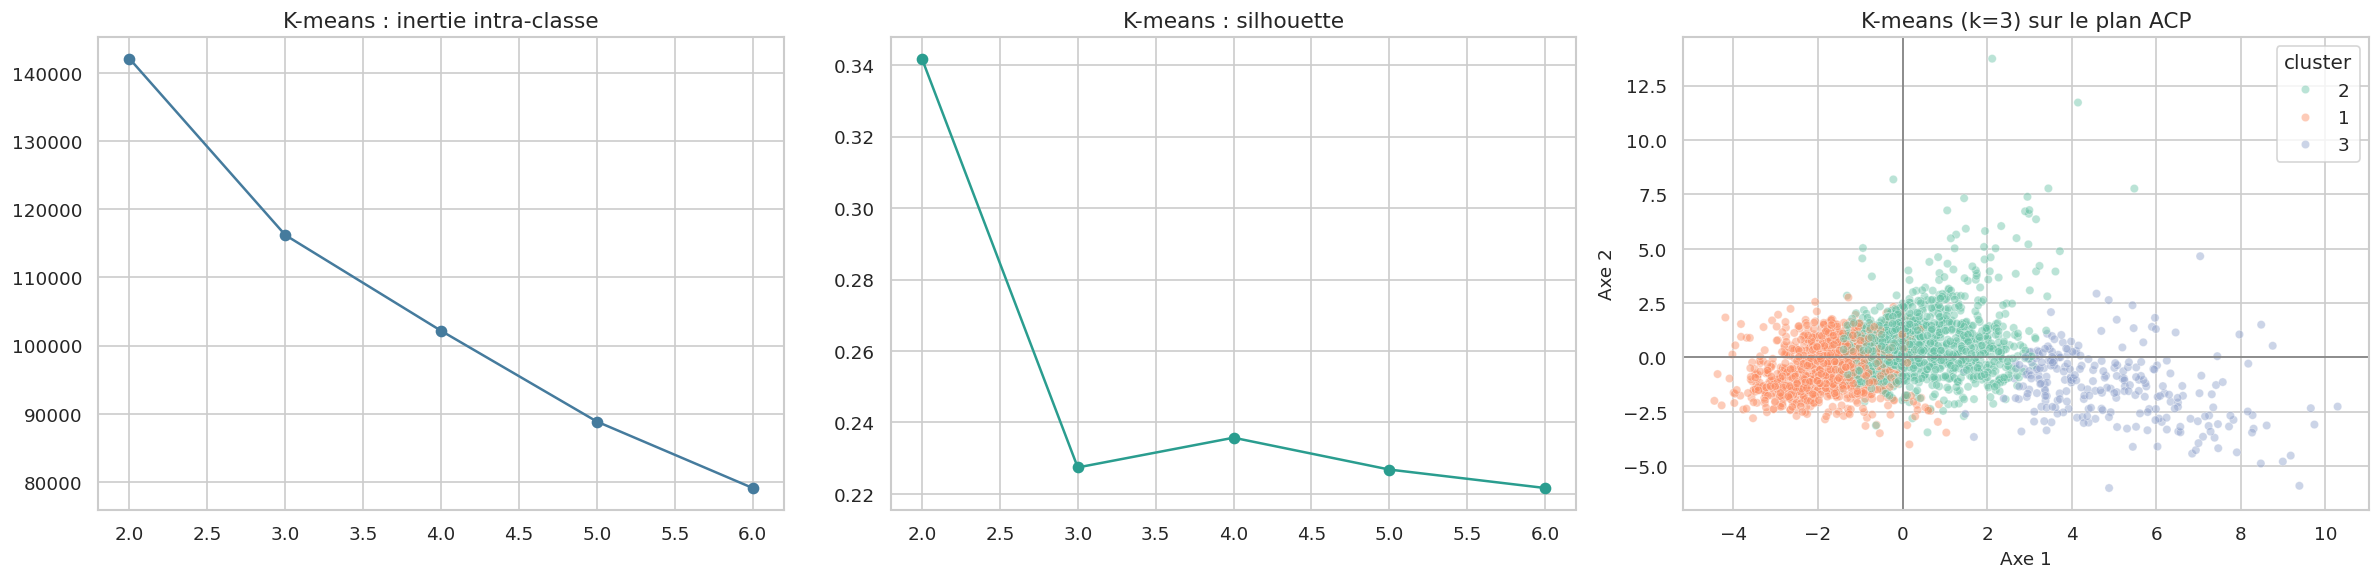

In [8]:
k_values = list(range(2, 7))
kmeans_eval = []
for k in k_values:
    km = KMeans(n_clusters=k, n_init=30, random_state=42)
    labels = km.fit_predict(cluster_input) + 1
    kmeans_eval.append({'k': k, 'inertie_intra': km.inertia_, 'silhouette': silhouette_score(cluster_input, labels)})
kmeans_eval = pd.DataFrame(kmeans_eval)
display(kmeans_eval.round(4))

kmeans_labels = pd.Series(KMeans(n_clusters=3, n_init=30, random_state=42).fit_predict(cluster_input) + 1, index=acp_cluster_coords.index, name='Cluster k-means')
display(kmeans_labels.value_counts().sort_index().rename('effectif').to_frame())
display(cluster_centroids_table(acp_cluster_coords, kmeans_labels))
display(top_modalities_by_cluster(cluster_profile_df, kmeans_labels, cluster_vars, top_n=3))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(kmeans_eval['k'], kmeans_eval['inertie_intra'], marker='o', color='#457b9d')
axes[0].set_title('K-means : inertie intra-classe')
axes[1].plot(kmeans_eval['k'], kmeans_eval['silhouette'], marker='o', color='#2a9d8f')
axes[1].set_title('K-means : silhouette')
plot_clusters_on_factor_plane(row_coords_pca, kmeans_labels, 'K-means (k=3) sur le plan ACP', ax=axes[2])
plt.tight_layout()
plt.show()



Le `k-means` fait ressortir trois profils assez lisibles :
- un pole plus **professionnalisant** ;
- un pole plus **generaliste / volumineux** ;
- et un pole plus **selectif**, avec **mentions tres elevees** et **acces plus difficile**.



### 2 : ACH sur l'ACP

On applique ensuite une **classification hierarchique** sur le meme espace factoriel, pour voir si la structure retrouvee par K-means tient encore avec une autre methode.



,k,silhouette,calinski_harabasz,davies_bouldin,taille_min_cluster
0,2,0.3926,3868.4642,1.0446,1370
1,3,0.1935,3860.0146,1.5178,1370
2,4,0.2022,3416.8946,1.3044,153
3,5,0.1518,3175.1537,1.4497,153
4,6,0.1407,3042.8578,1.3759,153


,effectif
Cluster ACH,
1,7804
2,1370
3,5078


,Axe 1,Axe 2,Axe 3,Axe 4,Axe 5
cluster,,,,,
1,0.325,0.642,-0.512,0.405,-0.228
2,4.835,-1.531,0.486,-0.031,0.915
3,-1.805,-0.573,0.656,-0.615,0.104


,cluster,variable,modalite,part_cluster,indice_surrepr
0,1,Filière,IFSI,4.4,1.81
1,1,Filière,EFTS,2.9,1.73
2,1,Filière,Licence_Las,5.8,1.60
3,2,Filière,CPGE,34.8,5.03
4,2,Filière,PASS,5.3,2.65
...,...,...,...,...,...
61,1,Statut,Public,74.9,0.96
62,2,Statut,Public,88.7,1.14
63,2,Statut,Privé,11.3,0.51
64,3,Statut,Public,79.8,1.02


Cluster ACH,1,2,3
Cluster k-means,,,
1,1135,6,4844
2,6388,127,215
3,281,1237,19


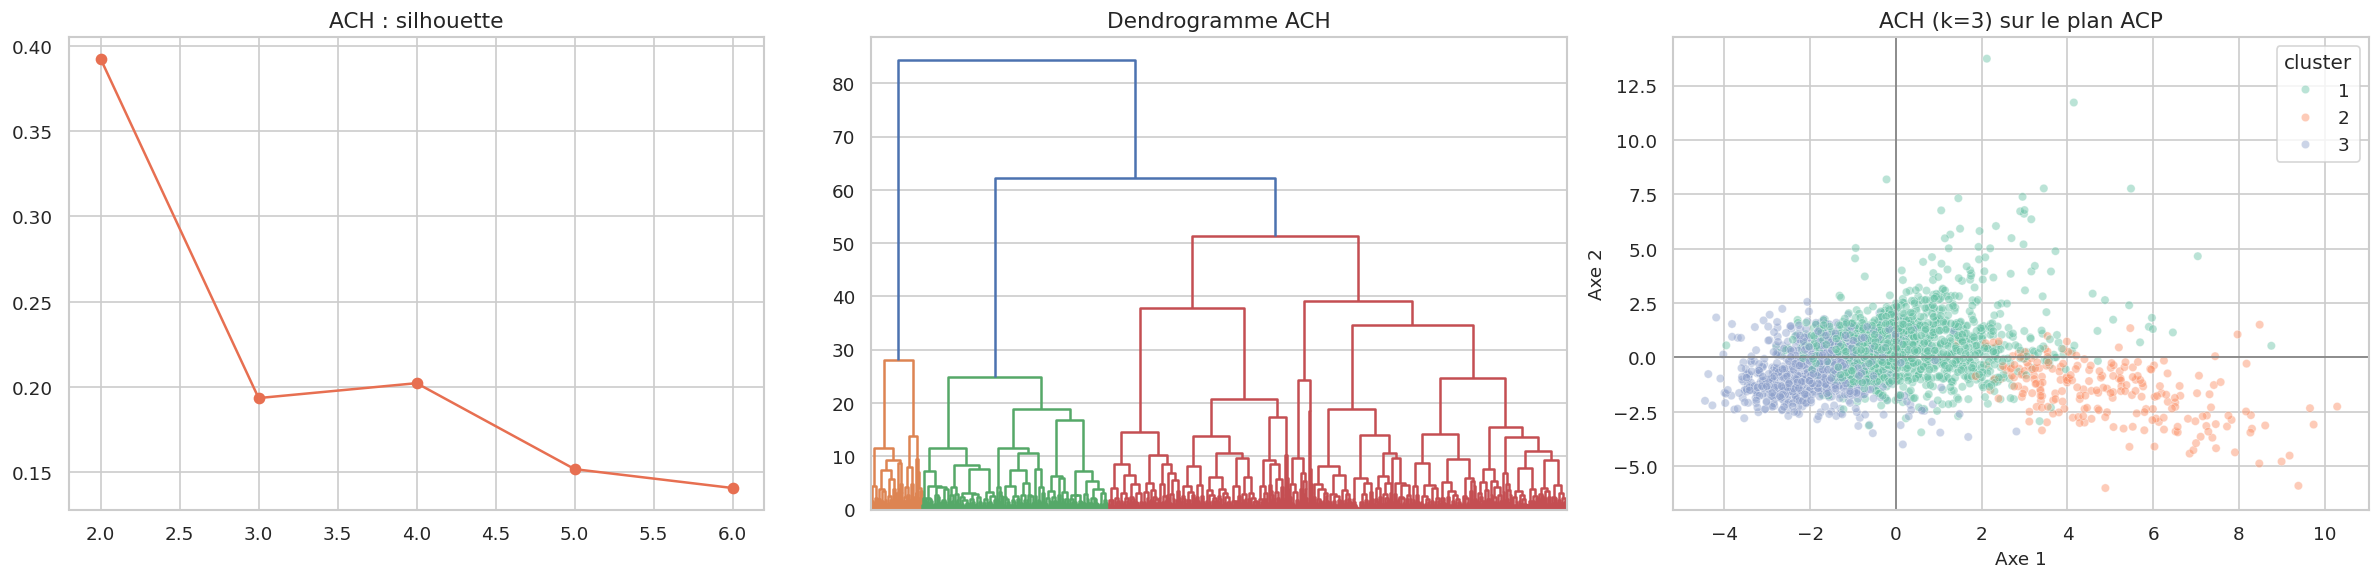

In [9]:
ahc_eval = []
for k in k_values:
    ahc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = ahc.fit_predict(cluster_input) + 1
    size_counts = pd.Series(labels).value_counts()
    ahc_eval.append({'k': k, 'silhouette': silhouette_score(cluster_input, labels), 'calinski_harabasz': calinski_harabasz_score(cluster_input, labels), 'davies_bouldin': davies_bouldin_score(cluster_input, labels), 'taille_min_cluster': int(size_counts.min())})
ahc_eval = pd.DataFrame(ahc_eval)
display(ahc_eval.round(4))

sample_idx = acp_cluster_coords.sample(n=min(1200, len(acp_cluster_coords)), random_state=42).index
linkage_sample = linkage(acp_cluster_coords.loc[sample_idx].to_numpy(), method='ward')

ahc_labels = pd.Series(AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(cluster_input) + 1, index=acp_cluster_coords.index, name='Cluster ACH')
display(ahc_labels.value_counts().sort_index().rename('effectif').to_frame())
display(cluster_centroids_table(acp_cluster_coords, ahc_labels))
display(top_modalities_by_cluster(cluster_profile_df, ahc_labels, cluster_vars, top_n=3))
display(pd.crosstab(kmeans_labels, ahc_labels))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(ahc_eval['k'], ahc_eval['silhouette'], marker='o', color='#e76f51')
axes[0].set_title('ACH : silhouette')
dendrogram(linkage_sample, no_labels=True, color_threshold=None, ax=axes[1])
axes[1].set_title('Dendrogramme ACH')
plot_clusters_on_factor_plane(row_coords_pca, ahc_labels, 'ACH (k=3) sur le plan ACP', ax=axes[2])
plt.tight_layout()
plt.show()



L'**ACH** retrouve globalement les mêmes données que le `k-means`. Les etiquettes changent un peu, mais on retrouve bien les grands profils **professionnalisants**, **generalistes** et **tres selectifs**.



### Pourquoi regarder aussi `k=5` ?

Comme pour l' ACM, la solution en `3` clusters est la plus simple pour l'analyse principale. Mais la version en `5` clusters permet de voir si certains sous-profils se separent un peu plus finement.



In [10]:
kmeans_labels_5 = pd.Series(KMeans(n_clusters=5, random_state=42, n_init=20).fit_predict(cluster_input) + 1, index=acp_cluster_coords.index, name='Cluster k-means (k=5)')
ahc_labels_5 = pd.Series(AgglomerativeClustering(n_clusters=5, linkage='ward').fit_predict(cluster_input) + 1, index=acp_cluster_coords.index, name='Cluster ACH (k=5)')
display(kmeans_labels_5.value_counts().sort_index().rename('effectif').to_frame())
display(ahc_labels_5.value_counts().sort_index().rename('effectif').to_frame())
display(pd.crosstab(kmeans_labels_5, ahc_labels_5))



,effectif
Cluster k-means (k=5),
1,5005
2,3743
3,1523
4,402
5,3579


,effectif
Cluster ACH (k=5),
1,5078
2,1370
3,5022
4,153
5,2629


Cluster ACH (k=5),1,2,3,4,5
Cluster k-means (k=5),,,,,
1,182,115,3061,0,1647
2,3317,5,274,0,147
3,16,1244,262,0,1
4,0,2,244,153,3
5,1563,4,1181,0,831


La partition en `5` groupes apporte du detail, mais elle redecoupe surtout des profils deja visibles. Comme pour l'ACM, **`k=3` reste le meilleur compromis** entre finesse et lisibilite.



### 3 : GMM sur l'ACP

On finit par un **Gaussian Mixture Model**. Il autorise des groupes plus souples, ce qui est utile quand les frontieres sont moins nettes dans l'espace factoriel.



,k,BIC,silhouette
0,2,239239.5215,0.2978
1,3,233870.3211,0.1788
2,4,230017.0190,0.1812
3,5,228348.9499,0.1502
4,6,226444.4490,0.1140


,effectif
Cluster GMM,
1,2626
2,8840
3,2786


,Axe 1,Axe 2,Axe 3,Axe 4,Axe 5
cluster,,,,,
1,0.203,1.546,-0.936,-0.387,-0.042
2,-1.142,-0.188,0.237,0.058,-0.022
3,3.431,-0.860,0.131,0.180,0.109


,cluster,variable,modalite,part_cluster,indice_surrepr
0,1,Filière,IFSI,9.2,3.82
1,1,Filière,Licence,51.6,2.41
2,1,Filière,BUT,13.4,2.33
3,2,Filière,BTS,57.5,1.53
4,2,Filière,EFTS,2.0,1.19
...,...,...,...,...,...
61,1,Statut,Privé,18.8,0.85
62,2,Statut,Privé,24.8,1.13
63,2,Statut,Public,75.2,0.96
64,3,Statut,Public,83.6,1.07


Cluster GMM,1,2,3
Cluster k-means,,,
1,214,5685,86
2,2402,3155,1173
3,10,0,1527


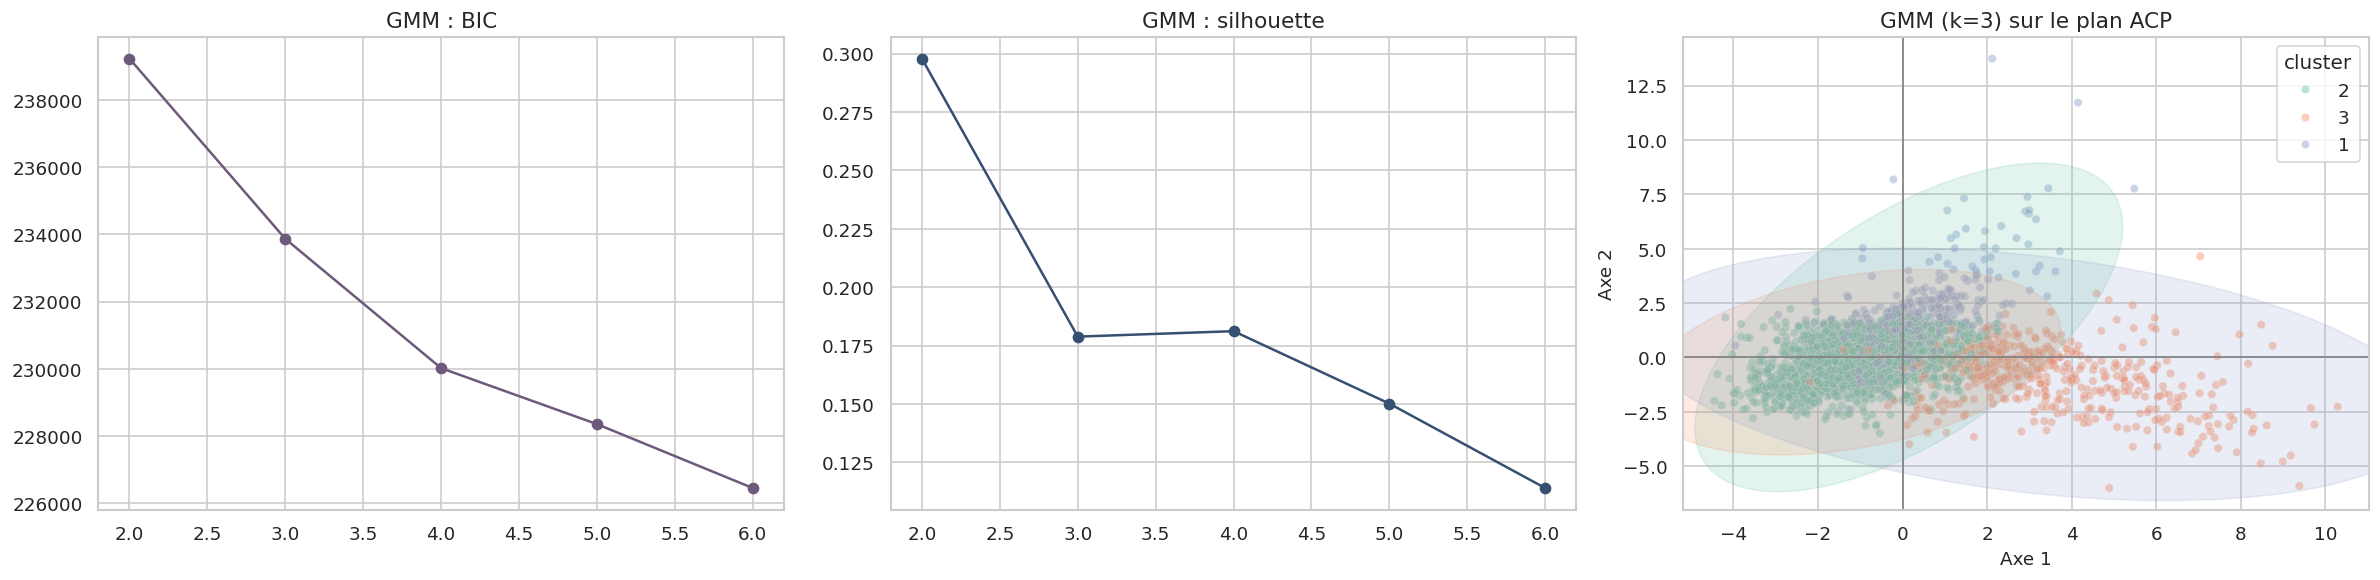

In [11]:
gmm_eval = []
for k in k_values:
    gmm = GaussianMixture(n_components=k, covariance_type='full', n_init=10, random_state=42)
    labels = gmm.fit_predict(cluster_input) + 1
    gmm_eval.append({'k': k, 'BIC': gmm.bic(cluster_input), 'silhouette': silhouette_score(cluster_input, labels)})
gmm_eval = pd.DataFrame(gmm_eval)
display(gmm_eval.round(4))

gmm_model = GaussianMixture(n_components=3, covariance_type='full', n_init=10, random_state=42)
gmm_labels = pd.Series(gmm_model.fit_predict(cluster_input) + 1, index=acp_cluster_coords.index, name='Cluster GMM')
display(gmm_labels.value_counts().sort_index().rename('effectif').to_frame())
display(cluster_centroids_table(acp_cluster_coords, gmm_labels))
display(top_modalities_by_cluster(cluster_profile_df, gmm_labels, cluster_vars, top_n=3))
display(pd.crosstab(kmeans_labels, gmm_labels))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].plot(gmm_eval['k'], gmm_eval['BIC'], marker='o', color='#6d597a')
axes[0].set_title('GMM : BIC')
axes[1].plot(gmm_eval['k'], gmm_eval['silhouette'], marker='o', color='#355070')
axes[1].set_title('GMM : silhouette')
plot_clusters_on_factor_plane(row_coords_pca, gmm_labels, 'GMM (k=3) sur le plan ACP', ax=axes[2])
palette = sns.color_palette('Set2', 3)
for i, color in enumerate(palette):
    mean = gmm_model.means_[i, :2]
    cov = gmm_model.covariances_[i][:2, :2]
    draw_ellipse(mean, cov, alpha=0.18, ax=axes[2], color=color)
plt.tight_layout()
plt.show()



Le **GMM** retrouve lui aussi les grands poles deja vus. Sa difference, c'est qu'il accepte mieux les zones de transition. On lira donc surtout ici une version plus **souple** des memes regroupements.



## Synthese des trois approches principales

Les trois methodes convergent globalement vers trois grands poles :
1. un pole plus **professionnalisant** ;
2. un pole plus **generaliste** ou plus **volumineux** ;
3. un pole plus **selectif** et plus **academiquement exigeant**.

Autrement dit, le clustering prolonge bien la lecture de l'ACP et rend plus lisibles les gradients deja visibles dans l'espace factoriel.



## Comparaison des methodes et des partitions



,Méthode,Silhouette,CH,DB
0,K-means,0.227,4540.3,1.475
1,ACH,0.194,3860.0,1.518
2,GMM,0.179,3007.8,1.952


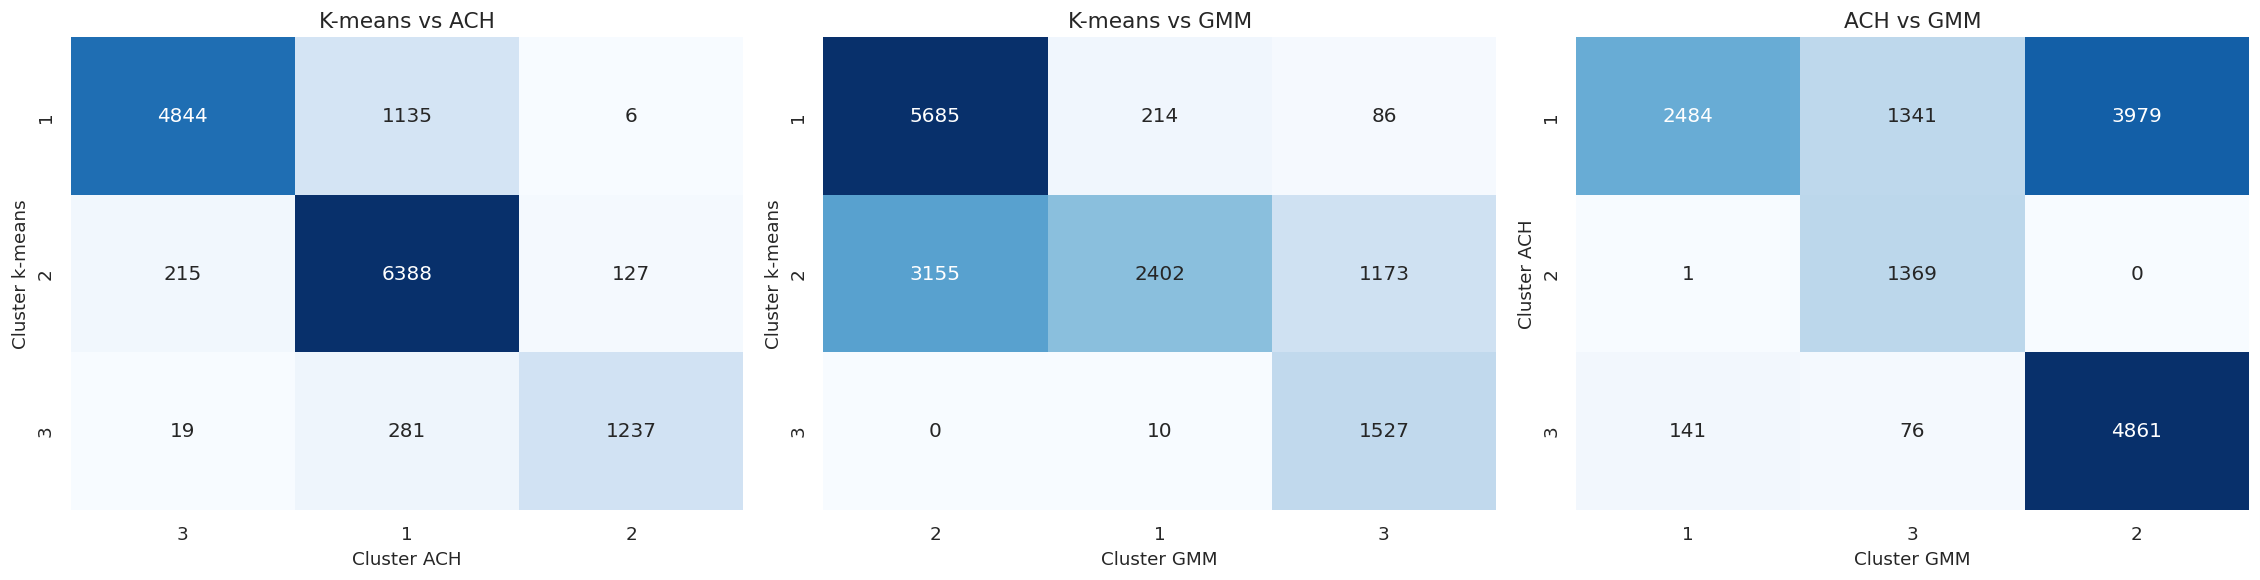

,Comparaison,ARI,NMI
0,K-means vs ACH,0.621,0.581
1,K-means vs GMM,0.273,0.362
2,ACH vs GMM,0.176,0.325


In [12]:
cluster_results = {'K-means': kmeans_labels.astype(int), 'ACH': ahc_labels.astype(int), 'GMM': gmm_labels.astype(int)}
comparison_df = pd.DataFrame([
    {'Méthode': name, 'Silhouette': silhouette_score(cluster_input, labels), 'CH': calinski_harabasz_score(cluster_input, labels), 'DB': davies_bouldin_score(cluster_input, labels)}
    for name, labels in cluster_results.items()
]).sort_values(['Silhouette', 'CH'], ascending=[False, False]).reset_index(drop=True)
display(comparison_df.style.format({'Silhouette': '{:.3f}', 'CH': '{:.1f}', 'DB': '{:.3f}'}))


def contingency_table(labels_a, labels_b):
    return pd.crosstab(labels_a, labels_b)


def diagonalize_contingency_table(table):
    rows, cols = list(table.index), list(table.columns)
    n = min(len(rows), len(cols))
    best_score, best_rows, best_cols = -1, rows, cols
    for row_perm in itertools.permutations(rows):
        for col_perm in itertools.permutations(cols):
            reordered = table.loc[list(row_perm), list(col_perm)]
            score = sum(reordered.iloc[i, i] for i in range(n))
            if score > best_score:
                best_score, best_rows, best_cols = score, list(row_perm), list(col_perm)
    return table.loc[best_rows, best_cols]

partition_pairs = [('K-means', 'ACH'), ('K-means', 'GMM'), ('ACH', 'GMM')]
agreement_rows = []
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, (name_a, name_b) in zip(axes, partition_pairs):
    table = diagonalize_contingency_table(contingency_table(cluster_results[name_a], cluster_results[name_b]))
    sns.heatmap(table, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'{name_a} vs {name_b}')
    agreement_rows.append({'Comparaison': f'{name_a} vs {name_b}', 'ARI': adjusted_rand_score(cluster_results[name_a], cluster_results[name_b]), 'NMI': normalized_mutual_info_score(cluster_results[name_a], cluster_results[name_b])})
plt.tight_layout()
plt.show()

display(pd.DataFrame(agreement_rows).sort_values('ARI', ascending=False).style.format({'ARI': '{:.3f}', 'NMI': '{:.3f}'}))



Les scores et tableaux de contingence montrent surtout que les trois methodes sont proche. Les groupes ne sont pas strictement identiques, mais la structure d'ensemble parait **robuste**. Cependant le GMM semble avoir des résultats différents des deux autres.



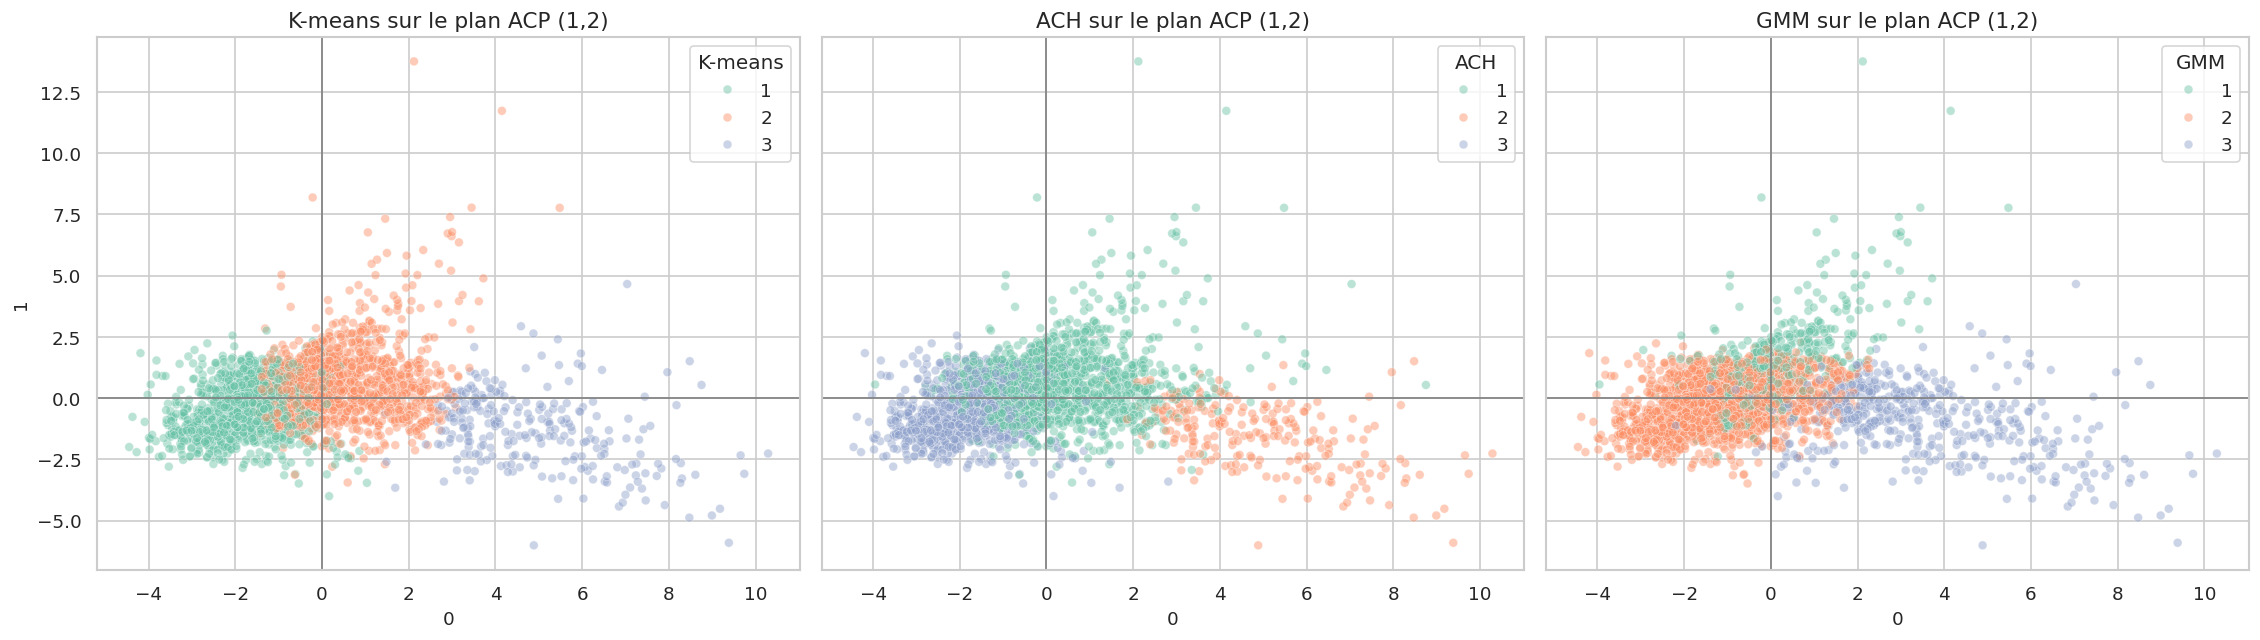

In [13]:
plot_sample = row_coords_pca[[0, 1]].copy()
if len(plot_sample) > 2500:
    plot_sample = plot_sample.sample(2500, random_state=42)
for method, labels in cluster_results.items():
    plot_sample[method] = labels.loc[plot_sample.index].astype(str)
all_levels = sorted({label for method in ['K-means', 'ACH', 'GMM'] for label in plot_sample[method].unique()}, key=int)
palette = {level: color for level, color in zip(all_levels, sns.color_palette('Set2', n_colors=len(all_levels)))}
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), sharex=True, sharey=True)
for ax, method in zip(axes, ['K-means', 'ACH', 'GMM']):
    sns.scatterplot(data=plot_sample, x=0, y=1, hue=method, hue_order=sorted(plot_sample[method].unique(), key=int), palette=palette, alpha=0.45, s=28, ax=ax)
    ax.axhline(0, color='grey', lw=1)
    ax.axvline(0, color='grey', lw=1)
    ax.set_title(f'{method} sur le plan ACP (1,2)')
plt.tight_layout()
plt.show()



La comparaison visuelle confirme l'idee principale : `k-means`, `ACH` et `GMM` retrouvent les **grandes oppositions** de l'espace ACP, meme si la geometrie des frontieres change un peu selon la methode, GMM étant un peu différent.



## Ouvertures : spectral clustering, DBSCAN et SBM

On ajoute trois méthodes complementaires. Elles sont interessantes, mais servent surtout ici d'appoint par rapport aux trois methodes principales.



,effectif
Cluster spectral,
1,3143
2,7050
3,2801
4,1258


,effectif
-1,13404
1,159
2,154
3,67
4,93
5,16
6,26
7,100
8,20
9,15


,effectif
Cluster SBM,
1,9053
2,3832
3,1367


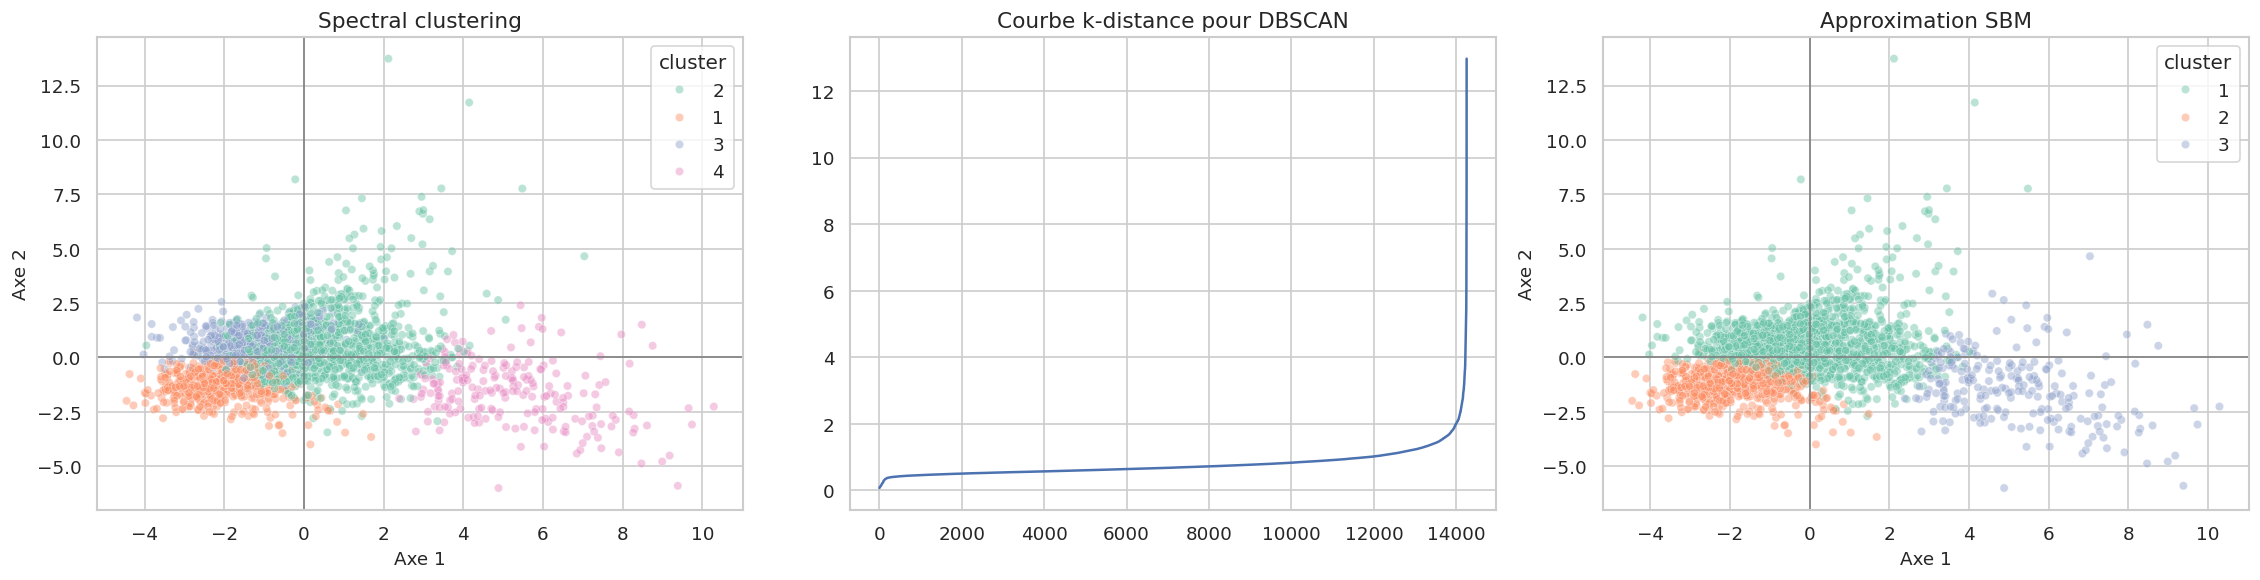

In [ ]:
spectral_labels = pd.Series(
    SpectralClustering(n_clusters=4, affinity='nearest_neighbors', n_neighbors=50, assign_labels='kmeans', random_state=42).fit_predict(cluster_input) + 1,
    index=acp_cluster_coords.index,
    name='Cluster spectral'
)
display(spectral_labels.value_counts().sort_index().rename('effectif').to_frame())

dbscan_min_samples = max(4, 2 * cluster_input.shape[1])
nn = NearestNeighbors(n_neighbors=dbscan_min_samples, metric='euclidean').fit(cluster_input)
distances, _ = nn.kneighbors(cluster_input)
kdist = np.sort(distances[:, -1])
dbscan_model = DBSCAN(eps=0.4, min_samples=dbscan_min_samples, metric='euclidean')
dbscan_raw = dbscan_model.fit_predict(cluster_input)
dbscan_labels = pd.Series(np.where(dbscan_raw == -1, -1, dbscan_raw + 1), index=acp_cluster_coords.index)
display(dbscan_labels.value_counts().sort_index().rename('effectif').to_frame())

A = kneighbors_graph(cluster_input, n_neighbors=20, mode='connectivity', include_self=False)
A = ((A + A.T) > 0).astype(int).tocsr()
embedding = SpectralEmbedding(n_components=3, affinity='precomputed', random_state=42).fit_transform(A)
sbm_labels = pd.Series(KMeans(n_clusters=3, random_state=42, n_init=20).fit_predict(embedding) + 1, index=acp_cluster_coords.index, name='Cluster SBM')
display(sbm_labels.value_counts().sort_index().rename('effectif').to_frame())

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
plot_clusters_on_factor_plane(row_coords_pca, spectral_labels, 'Spectral clustering', ax=axes[0])
axes[1].plot(kdist)
axes[1].set_title('Courbe k-distance pour DBSCAN')
plot_clusters_on_factor_plane(row_coords_pca, sbm_labels, 'Approximation SBM', ax=axes[2])
plt.tight_layout()
plt.show()



### Lecture rapide de ces trois ouvertures

- Le **spectral clustering** peut faire remonter quelques sous-groupes similaires au k-means (logique)
- **DBSCAN** on voit (avant le coude) que 80 % des donnnées sont très proches.
- Le **SBM** apporte une lecture intéressante et simplifie la structure par rapport au spectral clsutering.
Donc, pour l'etude principale, les methodes les plus convaincantes restent bien :
- **K-means** ;
- **ACH** ;
- **GMM**.
